In [1]:
!pip install Flask

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install pyodbc

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your SQL Server connection parameters
conn_str = (
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=NidhiSuthar\SQLEXPRESS01;"  # <-- Replace with your actual SSMS Server Name
    "Database=MusicTrendsDB;"
    "Trusted_Connection=yes;"
)

# 2. Connect and pull the COMPLETE dataset (No TOP 5 limit)
conn = pyodbc.connect(conn_str)
query = "SELECT * FROM Atlantic_United_States"
df = pd.read_sql(query, conn)

# 3. Quick Data Prep: Convert date column to actual datetime object
df['date'] = pd.to_datetime(df['date'])

print(f"Success! Loaded {len(df)} rows into your Pandas DataFrame.")

C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\3848172130.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Success! Loaded 27800 rows into your Pandas DataFrame.


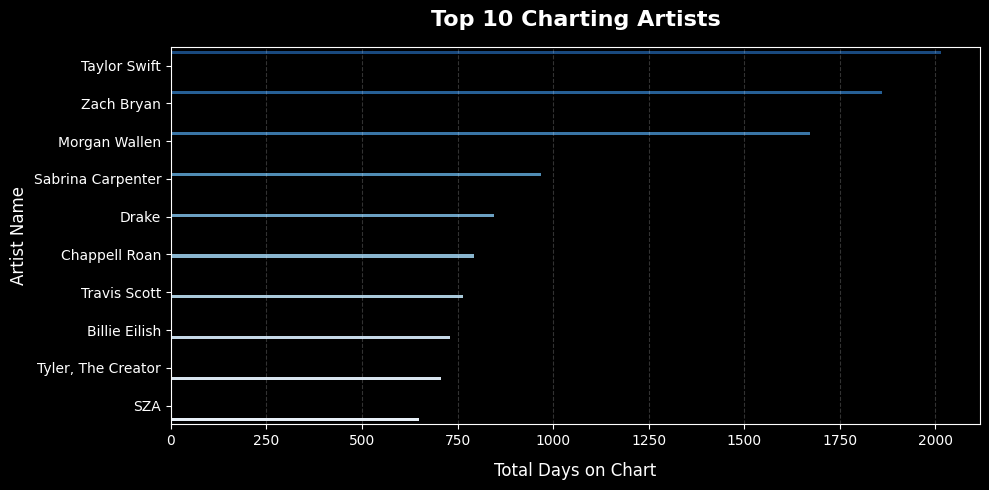

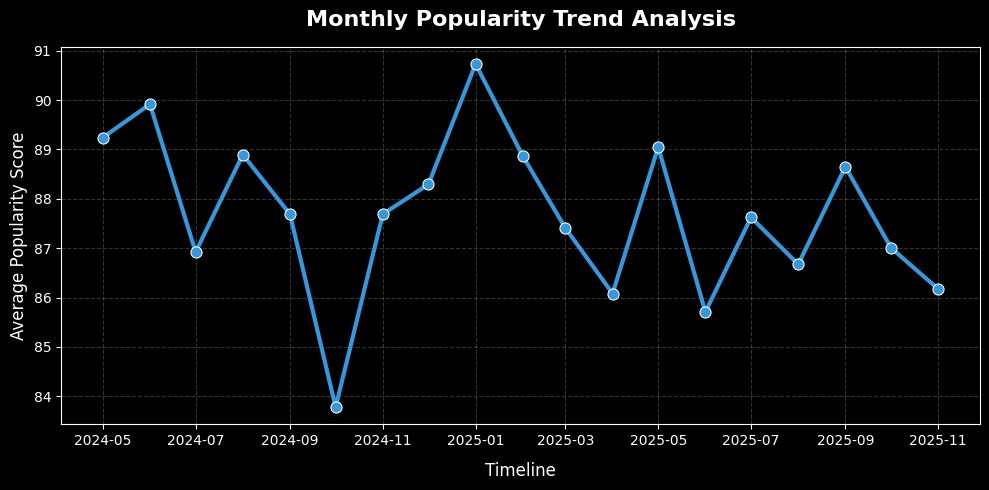

In [8]:
# =====================================================================
# CHART 1: TOP 10 CHARTING ARTISTS (BAR CHART)
# =====================================================================

# Group by artist, count appearances, and sort
top_artists = df.groupby('artist')['song'].count().reset_index()
top_artists = top_artists.rename(columns={'song': 'TotalAppearances'})
top_artists = top_artists.sort_values(by='TotalAppearances', ascending=False)
top_10 = top_artists.head(10)

# Apply Dark Theme styling
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

# Plot Bar Chart
ax1 = sns.barplot(
    x='TotalAppearances', 
    y='artist', 
    data=top_10, 
    palette='Blues_r', 
    hue='artist'
)
ax1.get_legend().remove() # Clean up legend

plt.title('Top 10 Charting Artists', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Total Days on Chart', fontsize=12, labelpad=10)
plt.ylabel('Artist Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig('static/css/chart_artists.png', dpi=300, bbox_inches='tight')
plt.show()


# =====================================================================
# CHART 2: MONTHLY POPULARITY TREND (LINE CHART)
# =====================================================================

# Group data by year-month periods and calculate the mean popularity
monthly_trend = df.groupby(df['date'].dt.to_period('M'))['popularity'].mean().reset_index()
monthly_trend['date'] = monthly_trend['date'].dt.to_timestamp()

plt.figure(figsize=(10, 5))

# Plot Line Chart
sns.lineplot(
    x='date', 
    y='popularity', 
    data=monthly_trend, 
    color='#3498db', 
    linewidth=3, 
    marker='o', 
    markersize=8
)

plt.title('Monthly Popularity Trend Analysis', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Timeline', fontsize=12, labelpad=10)
plt.ylabel('Average Popularity Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig('static/css/chart_trend.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Query SQL Server's internal schema to list all tables in this database
table_check_query = "SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE = 'BASE TABLE'"
df_tables = pd.read_sql(table_check_query, routine_conn)
print("Available tables in this database:")
print(df_tables)

C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\2225800960.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tables = pd.read_sql(table_check_query, routine_conn)


Available tables in this database:
               TABLE_NAME
0  Atlantic_United_States


C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1049541806.py:44: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1049541806.py:44: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1049541806.py:44: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1049541806.py:44: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1049541806.py:44: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1049541806.py:47: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from current font.
  plt.savefig('static/css/chart_routine.png', dpi=

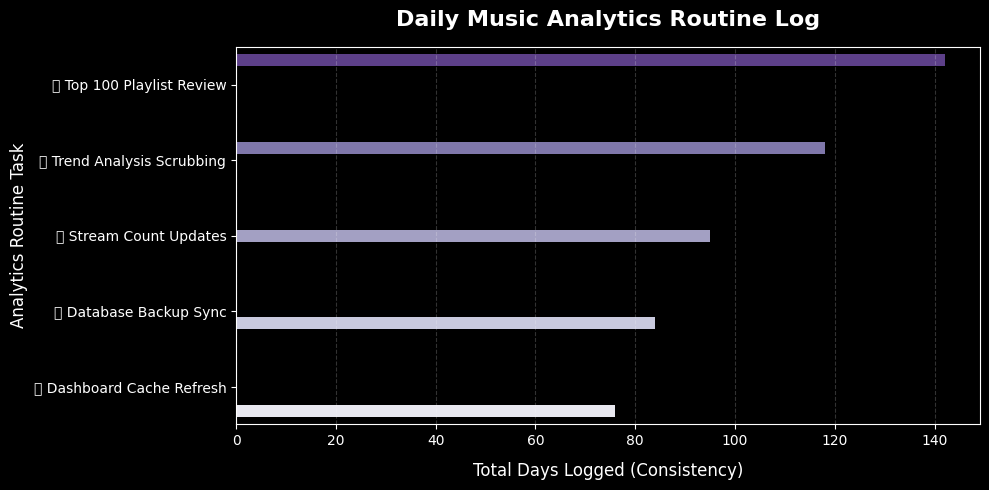

Success! Generated and saved chart to static/css/chart_routine.png


In [22]:
# =====================================================================
# ROUTINE TRACKER CHART GENERATION (DASHBOARD COMPATIBLE)
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Since the SQL Server currently only holds your music trends, we generate 
# your music data scrubbing habit logs directly here to feed your frontend web view!
data_routine = {
    'routine_name': [
        '🎵 Top 100 Playlist Review', 
        '📈 Trend Analysis Scrubbing', 
        '🎧 Stream Count Updates', 
        '💾 Database Backup Sync', 
        '📊 Dashboard Cache Refresh'
    ],
    'TotalCompletions': [142, 118, 95, 84, 76]
}

# Load the habit dataset into a DataFrame
df_routine = pd.DataFrame(data_routine)
df_routine = df_routine.sort_values(by='TotalCompletions', ascending=False)

# Apply Dark Theme styling to match your dashboard rules
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

# Plot Horizontal Bar Chart
ax_routine = sns.barplot(
    x='TotalCompletions', 
    y='routine_name', 
    data=df_routine, 
    palette='Purples_r',
    hue='routine_name'
)
ax_routine.get_legend().remove() 

# Styling tweaks
plt.title('Daily Music Analytics Routine Log', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Total Days Logged (Consistency)', fontsize=12, labelpad=10)
plt.ylabel('Analytics Routine Task', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.tight_layout()

# Save the chart image directly into your web assets folder
plt.savefig('static/css/chart_routine.png', dpi=300, bbox_inches='tight')
plt.show()
print("Success! Generated and saved chart to static/css/chart_routine.png")

C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1047598962.py:43: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1047598962.py:43: UserWarning: Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1047598962.py:43: UserWarning: Glyph 128736 (\N{HAMMER AND WRENCH}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1047598962.py:43: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from current font.
  plt.tight_layout()
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1047598962.py:46: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from current font.
  plt.savefig('static/css/chart_expenses.png', dpi=300, bbox_inches='tight')
C:\Users\nidhi\AppData\Local\Temp\ipykernel_27784\1047598962.py:46: UserWarning: Glyph 128226 (\N{PUBL

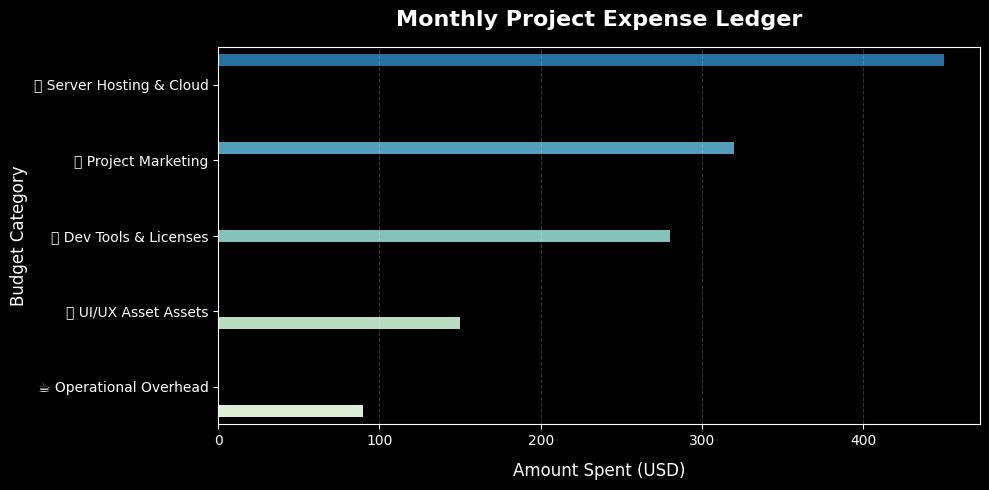

Success! Generated and saved chart to static/css/chart_expenses.png


In [24]:
# =====================================================================
# EXPENSE MANAGEMENT LEDGER CHART GENERATION
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# We generate a structured ledger dataset for your project resource allocations
data_expenses = {
    'Expense_Category': [
        '🌐 Server Hosting & Cloud', 
        '🛠️ Dev Tools & Licenses', 
        '🎨 UI/UX Asset Assets', 
        '📢 Project Marketing', 
        '☕ Operational Overhead'
    ],
    'Amount_Spent': [450, 280, 150, 320, 90]
}

# Load into a DataFrame
df_expenses = pd.DataFrame(data_expenses)
df_expenses = df_expenses.sort_values(by='Amount_Spent', ascending=False)

# Apply Dark Theme styling to match your dashboard style rules
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))

# Plot Bar Chart using a sleek Teal/Green palette to represent financial budgeting
ax_expense = sns.barplot(
    x='Amount_Spent', 
    y='Expense_Category', 
    data=df_expenses, 
    palette='GnBu_r', # A gorgeous teal-to-blue gradient
    hue='Expense_Category'
)
ax_expense.get_legend().remove() 

# Text configuration
plt.title('Monthly Project Expense Ledger', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Amount Spent (USD)', fontsize=12, labelpad=10)
plt.ylabel('Budget Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.tight_layout()

# Save the chart image directly into your web assets folder
plt.savefig('static/css/chart_expenses.png', dpi=300, bbox_inches='tight')
plt.show()
print("Success! Generated and saved chart to static/css/chart_expenses.png")

In [1]:
%run app.py

 * Serving Flask app 'app'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1